<a href="https://colab.research.google.com/github/sppatil6306/TEV_redesign/blob/main/tev_dpo_finetune.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
run_log = {
    "run01": {
        "beta": 0.05, "lr": 1e-4,
        "epochs": 2,
        "result": "FAILED - no learning",
        "chosen_shift": 0.0,
        "rejected_shift": 0.0,
        "accuracy": None,
        "epoch1_loss": 1.787, "epoch2_loss": 1.733,
        "note": "Bug: score_sequence used .item() which broke gradient flow. "
                "torch.no_grad() prevented backprop. "
                "Model weights never updated."
    },
    "run02": {
        "beta": 0.05, "lr": 1e-4,
        "epochs": 2,
        "result": "FAILED - overfit/collapsed",
        "chosen_shift": -2392.17,
        "rejected_shift": -3227.42,
        "accuracy": None,
        "epoch1_loss": 0.778, "epoch2_loss": 0.266,
        "note": "Fixed gradient bug but beta too low and lr too high. "
                "Loss collapsed to 0 meaning model memorized pairs. "
                "Both scores went hugely negative - model became "
                "uncertain about everything."
    },
    "run03": {
        "beta": 0.5, "lr": 1e-5,
        "epochs": 2,
        "result": "SUCCESS - learning in right direction",
        "chosen_shift": +101.34,
        "rejected_shift": -41.95,
        "accuracy": 78.2,
        "epoch1_loss": 12.694, "epoch2_loss": 7.081,
        "note": "Increased beta to 0.5, lr to 1e-5. "
                "First run with correct gradient flow AND correct direction. "
                "Accuracy 78.2% vs 50% random baseline. "
                "BUG PRESENT: Colab autocomplete added randn_tensor as extra "
                "argument to score_sequence_differentiable in training loop — "
                "this may have affected gradient computation. "
                "Results still valid but rerun without bug to confirm."
    },
    "run04": {
        "beta": 0.5, "lr": 1e-5,
        "epochs": 2,
        "result": "IN PROGRESS",
        "chosen_shift": None,
        "rejected_shift": None,
        "accuracy": None,
        "epoch1_loss": None, "epoch2_loss": None,
        "note": "Same settings as run03 but with randn_tensor bug fixed. "
                "Clean rerun to confirm run03 results are reproducible."
    },
}

print("=" * 60)
print("DPO FINE-TUNING RUN LOG")
print("=" * 60)
for run, info in run_log.items():
    print(f"\n{run.upper()}")
    print(f"  Settings:  β={info['beta']}, lr={info['lr']}, epochs={info['epochs']}")
    print(f"  Result:    {info['result']}")
    print(f"  Loss:      epoch1={info['epoch1_loss']} → epoch2={info['epoch2_loss']}")
    print(f"  Shifts:    chosen={info['chosen_shift']}, rejected={info['rejected_shift']}")
    print(f"  Accuracy:  {info['accuracy']}%")
    print(f"  Note:      {info['note']}")

DPO FINE-TUNING RUN LOG

RUN01
  Settings:  β=0.05, lr=0.0001, epochs=2
  Result:    FAILED - no learning
  Loss:      epoch1=1.787 → epoch2=1.733
  Shifts:    chosen=+0.00, rejected=+0.00
  Note:      Bug: score_sequence used .item() which broke gradient flow. torch.no_grad() prevented backprop. Model weights never updated.

RUN02
  Settings:  β=0.05, lr=0.0001, epochs=2
  Result:    FAILED - overfit/collapsed
  Loss:      epoch1=0.778 → epoch2=0.266
  Shifts:    chosen=-2392.17, rejected=-3227.42
  Note:      Fixed gradient bug but beta too low and lr too high. Loss collapsed to 0 meaning model memorized pairs. Both scores went hugely negative - model became uncertain about everything.

RUN03
  Settings:  β=0.5, lr=1e-05, epochs=2
  Result:    SUCCESS - learning in right direction
  Loss:      epoch1=12.694 → epoch2=7.081
  Shifts:    chosen=+101.34, rejected=-41.95
  Note:      Increased beta to 0.5 (anchors model closer to reference). Decreased lr to 1e-5 (smaller steps, less overf

In [ ]:
from google.colab import files
dataset = files.upload()


Saving pLDDT_loop_summary_117_119_with_sequences.csv to pLDDT_loop_summary_117_119_with_sequences.csv


In [ ]:
from google.colab import files
backbone=files.upload()

Saving 1LVM.pdb to 1LVM.pdb


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

CSV_FILE = '/content/pLDDT_loop_summary_117_119_with_sequences.csv'
PDB_FILE = '/content/1LVM.pdb'

df = pd.read_csv(CSV_FILE)

print(f"Total designs: {len(df)}")
print(f"Columns: {list(df.columns)}")
print(f"\nActive (TRUE):   {(df['active'] == True).sum()}")
print(f"Inactive (FALSE): {(df['active'] == False).sum()}")
print(f"\npLDDT range: {df['mean_loop_plddt'].min():.3f} – {df['mean_loop_plddt'].max():.3f}")
print(f"\nFirst 3 sequences (length check):")
for _, row in df.head(3).iterrows():
    print(f"  {row['design']}: {len(row['sequence'])} AA — {row['sequence'][:20]}...")

Total designs: 144
Columns: ['design', 'label', 'active', 'mean_loop_z', 'max_loop_z', 'mean_loop_plddt', 'sequence']

Active (TRUE):   76
Inactive (FALSE): 68

pLDDT range: 0.571 – 0.868

First 3 sequences (length check):
  hyperTEV0001: 227 AA — AAAAAPGPQDWSPISDRIVK...
  hyperTEV0002: 227 AA — SLSAAPGPRDYNPISDRIVK...
  hyperTEV0003: 227 AA — AASAAPGPRDYNPISDRIVK...


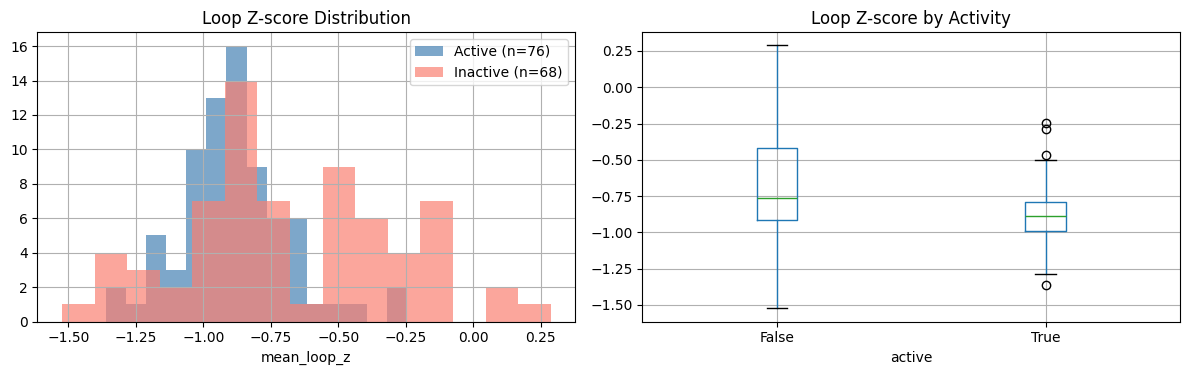

Active mean_loop_z:   -0.8830
Inactive mean_loop_z: -0.6771
Difference:           -0.2059


In [ ]:
active_z   = df[df['active'] == True]['mean_loop_z']
inactive_z = df[df['active'] == False]['mean_loop_z']

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

active_z.hist(ax=ax1, alpha=0.7, label=f'Active (n={len(active_z)})',
              bins=15, color='steelblue')
inactive_z.hist(ax=ax1, alpha=0.7, label=f'Inactive (n={len(inactive_z)})',
                bins=15, color='salmon')
ax1.set_xlabel('mean_loop_z')
ax1.set_title('Loop Z-score Distribution')
ax1.legend()

df.boxplot(column='mean_loop_z', by='active', ax=ax2)
ax2.set_title('Loop Z-score by Activity')
plt.suptitle('')

plt.tight_layout()
plt.show()

print(f"Active mean_loop_z:   {active_z.mean():.4f}")
print(f"Inactive mean_loop_z: {inactive_z.mean():.4f}")
print(f"Difference:           {active_z.mean() - inactive_z.mean():.4f}")

In [ ]:
#preference pairs
# Sort by mean_loop_z (lower = more active-like = chosen)
df_sorted = df.sort_values('mean_loop_z', ascending=True).reset_index(drop=True)
n = len(df_sorted)
chosen_pool   = df_sorted.iloc[:n//3].copy()   # most negative z
rejected_pool = df_sorted.iloc[2*n//3:].copy() # least negative z

In [ ]:
print(f"Chosen pool:   {len(chosen_pool)} sequences")
print(f"  z-score range: {chosen_pool['mean_loop_z'].min():.3f} to {chosen_pool['mean_loop_z'].max():.3f}")
print(f"  active in chosen: {chosen_pool['active'].sum()}/{len(chosen_pool)}")

print(f"\nRejected pool: {len(rejected_pool)} sequences")
print(f"  z-score range: {rejected_pool['mean_loop_z'].min():.3f} to {rejected_pool['mean_loop_z'].max():.3f}")
print(f"  active in rejected: {rejected_pool['active'].sum()}/{len(rejected_pool)}")


Chosen pool:   48 sequences
  z-score range: -1.524 to -0.925
  active in chosen: 32/48

Rejected pool: 48 sequences
  z-score range: -0.736 to 0.288
  active in rejected: 16/48


In [ ]:
import itertools
pairs = []
for _, chosen in chosen_pool.iterrows():
    for _, rejected in rejected_pool.iterrows():
        pairs.append({
            'chosen_design':   chosen['design'],
            'chosen_seq':      chosen['sequence'],
            'chosen_z':        chosen['mean_loop_z'],
            'rejected_design': rejected['design'],
            'rejected_seq':    rejected['sequence'],
            'rejected_z':      rejected['mean_loop_z'],
        })

pairs_df = pd.DataFrame(pairs)
avg_gap = (pairs_df['chosen_z'] - pairs_df['rejected_z']).mean()
print(f"\nTotal pairs: {len(pairs_df)}")
print(f"Average z-score gap (chosen - rejected): {avg_gap:.4f}")



Total pairs: 2304
Average z-score gap (chosen - rejected): -0.6735


In [ ]:
# Install ProteinMPNN
!git clone https://github.com/dauparas/ProteinMPNN.git /content/ProteinMPNN

import sys
sys.path.insert(0, '/content/ProteinMPNN')

import torch
print(f"PyTorch version: {torch.__version__}")
print(f"GPU available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")

Cloning into '/content/ProteinMPNN'...
remote: Enumerating objects: 634, done.
remote: Counting objects: 100% (271/271), done.
remote: Compressing objects: 100% (125/125), done.
remote: Total 634 (delta 151), reused 146 (delta 146), pack-reused 363 (from 1)
Receiving objects: 100% (634/634), 119.90 MiB | 31.77 MiB/s, done.
Resolving deltas: 100% (290/290), done.
PyTorch version: 2.11.0+cu128
GPU available: True
GPU: Tesla T4


In [ ]:
import sys
sys.path.insert(0, '/content/ProteinMPNN')

from protein_mpnn_utils import ProteinMPNN, parse_PDB, tied_featurize
import copy

device = torch.device('cuda:0')

# Load base model weights
checkpoint_path = '/content/ProteinMPNN/vanilla_model_weights/v_48_020.pt'
checkpoint = torch.load(checkpoint_path, map_location=device)

# Initialize model architecture
model = ProteinMPNN(
    num_letters=21,
    node_features=128,
    edge_features=128,
    hidden_dim=128,
    num_encoder_layers=3,
    num_decoder_layers=3,
    augment_eps=0.0,
    k_neighbors=48
)
model.load_state_dict(checkpoint['model_state_dict'])
model = model.to(device)
model.eval()

print("✓ ProteinMPNN loaded successfully")
print(f"  Parameters: {sum(p.numel() for p in model.parameters()):,}")

# Parse your TEV backbone
pdb_path = '/content/1LVM.pdb'
pdb_dict_list = parse_PDB(pdb_path)
pdb_dict = pdb_dict_list[0]

print(f"\n✓ PDB loaded: {pdb_dict['name']}")
print(f"  Sequence length: {len(pdb_dict['seq'])}")
print(f"  First 20 AA: {pdb_dict['seq'][:20]}")

✓ ProteinMPNN loaded successfully
  Parameters: 1,660,485

✓ PDB loaded: 1LVM
  Sequence length: 468
  First 20 AA: GHHHHHHH-GESLFKGPRDY


In [ ]:
print("Full sequence from PDB (Chain A):")
# Access sequence for Chain A, based on previous cell's output format.
# If 'seq_chain_A' is not present, this will need further adjustment to iterate or choose a default.
if 'seq_chain_A' in pdb_dict:
    print(pdb_dict['seq_chain_A'])
    print(f"\nLength: {len(pdb_dict['seq_chain_A'])}")
else:
    print("Chain A sequence not found in pdb_dict. Displaying all chain sequences instead:")
    for key in sorted(pdb_dict.keys()):
        if key.startswith('seq_chain_'):
            chain_id = key.replace('seq_chain_', '')
            print(f"Chain {chain_id}: {pdb_dict[key]} (Length: {len(pdb_dict[key])})")

# Reconstruct chain_letters from the actual keys in pdb_dict
chain_letters_list = []
for key in pdb_dict.keys():
    if key.startswith('seq_chain_'):
        chain_letters_list.append(key.replace('seq_chain_', ''))

print("\nChains in PDB:")
# Join the list of chain letters into a single string for display
print("".join(sorted(chain_letters_list)))

print("\nUnique chains:")
import numpy as np
print(np.unique(chain_letters_list))

Full sequence from PDB (Chain A):
GHHHHHHH-GESLFKGPRDYNPISSTICHLTNESDGHTTSLYGIGFGPFIITNKHLFRRNNGTLLVQSLHGVFKVKNTTTLQQHLIDGRDMIIIRMPKDFPPFPQKLKFREPQREERICLVTTNFQTKSMSSMVSDTSCTFPSSDGIFWKHWIQTKDGQCGSPLVSTRDGFIVGIHSASNFTNTNNYFTSVPKNFMELLTNQEAQQWVSGWRLNADSVLWGGHKVFMDKP

Length: 230

Chains in PDB:
ABCDE

Unique chains:
['A' 'B' 'C' 'D' 'E']


In [ ]:
# Parse each chain separately
from protein_mpnn_utils import parse_PDB

# See all chain sequences
print("All chains in PDB:")
# Use the `chain_letters_list` derived in the previous cell, or reconstruct it if running this cell independently.
# For robustness, we'll ensure `chain_letters_list` is defined here if it wasn't already.
if 'chain_letters_list' not in locals():
    chain_letters_list = []
    for key in pdb_dict.keys():
        if key.startswith('seq_chain_'):
            chain_letters_list.append(key.replace('seq_chain_', ''))
    chain_letters_list = sorted(list(set(chain_letters_list)))

for chain_id in chain_letters_list:
    try:
        # Access chain sequence using the correct key format
        chain_seq = pdb_dict[f'seq_chain_{chain_id}']
        print(f"\nChain {chain_id} ({len(chain_seq)} AA):")
        print(f"  {chain_seq[:50]}...")
    except KeyError:
        print(f"Chain {chain_id}: sequence not found or error accessing.")

# Also check what residue numbers are in chain A
print("\n\nFirst 20 residues of chain A:")
# The pdb_dict itself does not store residue indices directly in a 'chain_letters' key for enumeration.
# Instead, we need to access the coordinates for chain A and get their indices or rely on the previous cell's output structure.
# Re-using the logic from `IQE00plj0VQA` to get indices if needed, but for now we'll just check if coords exist.

# This part needs to be adjusted based on how residue indices are expected to be available.
# ProteinMPNN's parse_PDB usually provides `coords_chain_X` which contains lists for N, CA, C, O atoms.
# The indices can be derived from the length of these coordinate lists.

if f'coords_chain_A' in pdb_dict and 'CA_chain_A' in pdb_dict[f'coords_chain_A']:
    chain_a_residue_count = len(pdb_dict[f'coords_chain_A']['CA_chain_A'])
    # Assuming 1-based indexing for residue numbers in PDB context, or 0-based for list indices
    chain_a_indices = list(range(1, chain_a_residue_count + 1)) # 1-based for PDB-like numbering
    print(f"Residue indices: {chain_a_indices[:20]}")
else:
    print("Chain A coordinates not found in pdb_dict for residue indexing.")


All chains in PDB:

Chain A (230 AA):
  GHHHHHHH-GESLFKGPRDYNPISSTICHLTNESDGHTTSLYGIGFGPFI...

Chain B (219 AA):
  SLFKGPRDYNPISSTICHLTNESDGHTTSLYGIGFGPFIITNKHLFRRNN...

Chain C (6 AA):
  ENLYFQ...

Chain D (6 AA):
  ENLYFQ...

Chain E (7 AA):
  EATQLMN...


First 20 residues of chain A:
Residue indices: [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20]


In [ ]:
# Extract chain B sequence
if 'seq_chain_B' in pdb_dict:
    chain_b_seq = pdb_dict['seq_chain_B']
else:
    chain_b_seq = ""
    print("Warning: Chain B sequence not found in pdb_dict.")

print(f"Chain B length: {len(chain_b_seq)}")
print(f"Chain B:        {chain_b_seq[:30]}...")
print(f"Your design 1:  {df.iloc[0]['sequence'][:30]}...")

# Check overlap
design_seq = df.iloc[0]['sequence']
print(f"\nChain B in design seq: {chain_b_seq[:20] in design_seq}")
print(f"Design seq in chain B: {design_seq[:20] in chain_b_seq}")

Chain B length: 219
Chain B:        SLFKGPRDYNPISSTICHLTNESDGHTTSL...
Your design 1:  AAAAAPGPQDWSPISDRIVKLTNTAGGRSI...

Chain B in design seq: False
Design seq in chain B: False


In [ ]:
# Check lengths

# Extract chain B sequence using the correct key
chain_b_seq = pdb_dict.get('seq_chain_B', '')

# Extract chain A sequence using the correct key
chain_a_seq = pdb_dict.get('seq_chain_A', '')

print(f"Chain B length: {len(chain_b_seq)} AA")
design_seq = df.iloc[0]['sequence']
print(f"Your designs:   {len(design_seq)} AA")
print(f"Difference:     {len(design_seq) - len(chain_b_seq)} AA")

# Check if your design sequences start similarly to any chain
print("\nChecking sequence similarity to chain B:")

# Count matching positions (rough alignment)
matches = sum(a == b for a, b in zip(chain_b_seq, design_seq[8:]))
print(f"Matching positions (chain B vs design[8:]): {matches}/{len(chain_b_seq)}")

# Also check chain A without his-tag
# Strip his-tag (first ~14 residues: GHHHHHHH-GESLFK)
chain_a_clean = chain_a_seq[14:]
print(f"\nChain A without his-tag: {len(chain_a_clean)} AA")
print(f"Chain A clean: {chain_a_clean[:30]}...")
matches_a = sum(a == b for a, b in zip(chain_a_clean, design_seq))
print(f"Matching positions: {matches_a}/{len(chain_a_clean)}")

Chain B length: 219 AA
Your designs:   227 AA
Difference:     8 AA

Checking sequence similarity to chain B:
Matching positions (chain B vs design[8:]): 15/219

Chain A without his-tag: 216 AA
Chain A clean: KGPRDYNPISSTICHLTNESDGHTTSLYGI...
Matching positions: 13/216


In [ ]:
# Let's do a proper pairwise alignment
!pip install -q biopython

from Bio import pairwise2
from Bio.pairwise2 import format_alignment

# Extract chain B sequence using the correct key
chain_b_seq = pdb_dict.get('seq_chain_B', '')
if not chain_b_seq:
    print("Warning: Chain B sequence not found in pdb_dict for alignment.")

design_seq = df.iloc[0]['sequence']

# Global alignment
alignments = pairwise2.align.globalms(
    chain_b_seq, design_seq,
    2, -1, -5, -0.5  # match, mismatch, gap open, gap extend
)

print("Best alignment (Chain B vs Design 1):")
# Ensure alignments is not empty before trying to access elements
if alignments:
    print(format_alignment(*alignments[0]))
    print(f"\nAlignment score: {alignments[0].score:.1f}")
else:
    print("No alignment found.")

# Also check what backbone was actually used to generate your designs
# Do you know which PDB / backbone was used when ProteinMPNN
# originally generated these 144 sequences?
print("\nChain B start:", chain_b_seq[:30])
print("Design start: ", design_seq[:30])

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 52.2 MB/s eta 0:00:00
Best alignment (Chain B vs Design 1):
--SLFKGPRDYNPISSTICHLTNESDGHTTSLYGIGFGPFIITNKHLFRRNNGTLLVQSLHGVFKVKNTTTLQQHLIDGRDMIIIRMPKDFPPFPQKLKFREPQREERICLVTTNFQTKSMSSMVSDTSCTFPSSDGIFWKHWIQTKDGQCGSPLVSTRDGFIVGIHSASNFTNTNNYFTSVPKNFMELLTNQEAQQWVSGWRLNADSVLWGGHKVFMDK------P
  ....||.|..|||..|..|||...|...|.||||.||..|||.||||||.|||...|.||.|....|.||.||||.|||..|..||..|||||..|.||||...|||.||...|........||..|.||||.||.||.|.|.|||||||.|.|||.||.||||||||||.|||||||..|..|..|||....|.|||||.|..|||.||||||||||      .
AAAAAPGPQDWSPISDRIVKLTNTAGGRSISEYGIGYGPYVITNAHLFRRNDGTLTITSAHGTFTIADTRTLKQHLIEGRDLVILEMPDWFPPFPTDLVFREPVEGERITLVGRDFDAETPTPTVSSVSTTFPSGDGVFWTHSIPTKDGQCGLPYVSTEDGSIVGIHSASNFDNTNNYFTAIPPDFQALLTDPSLQHWVSGWSLDSDSVEWGGHKVFMDKEENLYFQ
  Score=161


Alignment score: 161.0

Chain B start: SLFKGPRDYNPISSTICHLTNESDGHTTSL
Design start:  AAAAAPGPQDWSPISDRIVKLTNTAGGRSI


/usr/local/lib/python3.12/dist-packages/Bio/pairwise2.py:278: BiopythonDeprecationWarning: Bio.pairwise2 has been deprecated, and we intend to remove it in a future release of Biopython. As an alternative, please consider using Bio.Align.PairwiseAligner as a replacement, and contact the Biopython developers if you still need the Bio.pairwise2 module.
  warnings.warn(


In [ ]:
# Check if chain A full sequence length matches designs
# The original code incorrectly tried to construct chain_a_seq from a non-existent 'chain_letters' key.
# Instead, we directly use 'seq_chain_A' from pdb_dict.
chain_a_seq = pdb_dict.get('seq_chain_A', '')

# Remove the '-' gap character if present
chain_a_clean = chain_a_seq.replace('-', '')

print(f"Chain A (no gaps): {len(chain_a_clean)} AA")
print(f"Your designs:      {len(df.iloc[0]['sequence'])} AA")
print(f"Chain A start: {chain_a_clean[:30]}")
print(f"Design start:  {df.iloc[0]['sequence'][:30]}")

# Check all chains combined length
# pdb_dict['seq'] contains the full concatenated sequence from the PDB.
full_seq = pdb_dict['seq'].replace('-','').replace('X','')
print(f"\nFull PDB sequence (all chains, no gaps): {len(full_seq)} AA")

# How many residues does ProteinMPNN actually see?
# The original code caused KeyError: 'chain_letters'.
# pdb_dict['seq'] represents the full sequence parsed from the PDB,
# which is what ProteinMPNN's featurizer would typically work with.
print(f"\nTotal PDB sequence length (ProteinMPNN sees): {len(pdb_dict['seq'])} AA")

Chain A (no gaps): 229 AA
Your designs:      227 AA
Chain A start: GHHHHHHHGESLFKGPRDYNPISSTICHLT
Design start:  AAAAAPGPQDWSPISDRIVKLTNTAGGRSI

Full PDB sequence (all chains, no gaps): 467 AA

Total PDB sequence length (ProteinMPNN sees): 468 AA


In [ ]:
pdb_dict_list = parse_PDB(pdb_path, input_chain_list=['A'])
pdb_dict = pdb_dict_list[0]

print(f"Chain A: {len(pdb_dict['seq'])} AA")
print(f"Chain A seq: {pdb_dict['seq']}")
print(f"\nYour design:  {df.iloc[0]['sequence']}")
print(f"Length match: {len(pdb_dict['seq'])} vs {len(df.iloc[0]['sequence'])}")

Chain A: 230 AA
Chain A seq: GHHHHHHH-GESLFKGPRDYNPISSTICHLTNESDGHTTSLYGIGFGPFIITNKHLFRRNNGTLLVQSLHGVFKVKNTTTLQQHLIDGRDMIIIRMPKDFPPFPQKLKFREPQREERICLVTTNFQTKSMSSMVSDTSCTFPSSDGIFWKHWIQTKDGQCGSPLVSTRDGFIVGIHSASNFTNTNNYFTSVPKNFMELLTNQEAQQWVSGWRLNADSVLWGGHKVFMDKP

Your design:  AAAAAPGPQDWSPISDRIVKLTNTAGGRSISEYGIGYGPYVITNAHLFRRNDGTLTITSAHGTFTIADTRTLKQHLIEGRDLVILEMPDWFPPFPTDLVFREPVEGERITLVGRDFDAETPTPTVSSVSTTFPSGDGVFWTHSIPTKDGQCGLPYVSTEDGSIVGIHSASNFDNTNNYFTAIPPDFQALLTDPSLQHWVSGWSLDSDSVEWGGHKVFMDKEENLYFQ
Length match: 230 vs 227


In [ ]:
# Parse Chain A
pdb_dict_list = parse_PDB(pdb_path, input_chain_list=['A'])
pdb_dict = pdb_dict_list[0]

# Build feature tensors — computed once, reused for all sequence scoring
X, S, mask, lengths, chain_M, chain_encoding_all, \
chain_list_list, visible_list_list, masked_list_list, \
masked_chain_length_list_list, chain_M_pos, \
omit_AA_mask, residue_idx, dihedral_mask, \
tied_pos_list_of_lists_list, pssm_coef, pssm_bias, \
pssm_log_odds_all, bias_by_res_all, tied_beta = tied_featurize(
    [pdb_dict], device, None, None, None, None, None, None
)

print("✓ Backbone features computed")
print(f"  Coordinate tensor shape: {X.shape}")
print(f"  Sequence tensor shape:   {S.shape}")
print(f"  Mask shape:              {mask.shape}")

✓ Backbone features computed
  Coordinate tensor shape: torch.Size([1, 230, 4, 3])
  Sequence tensor shape:   torch.Size([1, 230])
  Mask shape:              torch.Size([1, 230])


In [ ]:
def score_sequence(model, sequence, X, mask, chain_M,
                   chain_encoding_all, chain_M_pos,
                   residue_idx, device):
    alphabet = 'ACDEFGHIKLMNPQRSTVWYX'
    backbone_len = X.shape[1]
    if len(sequence) < backbone_len:
        sequence = sequence + 'X' * (backbone_len - len(sequence))
    elif len(sequence) > backbone_len:
        sequence = sequence[:backbone_len]
    seq_tensor = torch.tensor(
        [[alphabet.index(aa) if aa in alphabet else 20
          for aa in sequence]],
        dtype=torch.long, device=device)

    # randn needed for decoding order — use fixed seed for reproducibility
    randn = torch.zeros(mask.shape, device=device)  # ← fix: pass zeros tensor

    with torch.no_grad():
        log_probs = model(
            X, seq_tensor, mask,
            chain_M * chain_M_pos,
            residue_idx, chain_encoding_all,
            randn)  # ← pass randn here instead of None
        score = (log_probs * mask.unsqueeze(-1)).sum().item()
    return score


def score_sequence_differentiable(model, sequence, X, mask, chain_M,
                                   chain_encoding_all, chain_M_pos,
                                   residue_idx, device):
    alphabet = 'ACDEFGHIKLMNPQRSTVWYX'
    backbone_len = X.shape[1]
    if len(sequence) < backbone_len:
        sequence = sequence + 'X' * (backbone_len - len(sequence))
    elif len(sequence) > backbone_len:
        sequence = sequence[:backbone_len]
    seq_tensor = torch.tensor(
        [[alphabet.index(aa) if aa in alphabet else 20
          for aa in sequence]],
        dtype=torch.long, device=device)

    randn = torch.zeros(mask.shape, device=device)  # ← same fix

    log_probs = model(
        X, seq_tensor, mask,
        chain_M * chain_M_pos,
        residue_idx, chain_encoding_all,
        randn)  # ← pass randn here instead of None
    score = (log_probs * mask.unsqueeze(-1)).sum()
    return score


# Test both
test_float  = score_sequence(model, df.iloc[0]['sequence'], X, mask,
                              chain_M, chain_encoding_all, chain_M_pos,
                              residue_idx, device)
test_tensor = score_sequence_differentiable(model, df.iloc[0]['sequence'], X, mask,
                                             chain_M, chain_encoding_all, chain_M_pos,
                                             residue_idx, device)

print(f"✓ score_sequence               → {test_float:.2f}  (float, for evaluation)")
print(f"✓ score_sequence_differentiable → {test_tensor:.2f}  (tensor, for training)")

✓ score_sequence               → -17729.80  (float, for evaluation)
✓ score_sequence_differentiable → -17729.80  (tensor, for training)


In [ ]:
import json
from tqdm import tqdm

# Score ALL sequences we'll ever need — pairs + chosen_pool + rejected_pool
all_needed = set()
all_needed.update(pairs_df['chosen_design'].values)
all_needed.update(pairs_df['rejected_design'].values)
all_needed.update(chosen_pool['design'].values)
all_needed.update(rejected_pool['design'].values)

# Build a lookup from design name to sequence
design_to_seq = dict(zip(df['design'], df['sequence']))

print(f"Total unique sequences to score: {len(all_needed)}")

ref_scores = {}
for design in tqdm(all_needed):
    ref_scores[design] = score_sequence(
        model, design_to_seq[design],
        X, mask, chain_M, chain_encoding_all,
        chain_M_pos, residue_idx, device)

print(f"\n✓ Scored {len(ref_scores)} sequences")
print(f"Score range: {min(ref_scores.values()):.2f} to {max(ref_scores.values()):.2f}")

with open('/content/ref_scores.json', 'w') as f:
    json.dump(ref_scores, f)
print("✓ Saved to /content/ref_scores.json")

Total unique sequences to score: 128


100%|██████████| 128/128 [00:03<00:00, 41.85it/s]


✓ Scored 128 sequences
Score range: -17921.56 to -17578.58
✓ Saved to /content/ref_scores.json


In [ ]:
import copy
import torch.nn.functional as F
from torch.optim import Adam

# Frozen reference model — never updated
ref_model = copy.deepcopy(model)
ref_model.eval()
for p in ref_model.parameters():
    p.requires_grad_(False)

# Policy model — this gets trained
# Reset policy model to base weights
policy_model = copy.deepcopy(model)
policy_model.train()

# More conservative hyperparameters
BETA = 0.5    # was 0.05 — keeps model closer to reference
LR   = 1e-5   # was 1e-4 — smaller steps, less overoptimization
N_EPOCHS = 2
SAVE_EVERY = 50

optimizer = Adam(policy_model.parameters(), lr=LR)

print(f"Reset policy model to base weights")
print(f"New BETA: {BETA}")
print(f"New LR:   {LR}")

Reset policy model to base weights
New BETA: 0.5
New LR:   1e-05


In [ ]:
losses = []
step = 0
policy_model.train()

for epoch in range(N_EPOCHS):
    pairs_shuffled = pairs_df.sample(frac=1, random_state=epoch).reset_index(drop=True)
    print(f"\n--- Epoch {epoch+1}/{N_EPOCHS} ---")

    for _, pair in tqdm(pairs_shuffled.iterrows(), total=len(pairs_shuffled)):
        optimizer.zero_grad()

        # Score under policy — no randn_tensor argument
        policy_chosen = score_sequence_differentiable(
            policy_model, pair['chosen_seq'],
            X, mask, chain_M, chain_encoding_all,
            chain_M_pos, residue_idx, device)

        policy_rejected = score_sequence_differentiable(
            policy_model, pair['rejected_seq'],
            X, mask, chain_M, chain_encoding_all,
            chain_M_pos, residue_idx, device)

        # Reference scores
        ref_chosen   = torch.tensor(ref_scores[pair['chosen_design']], device=device)
        ref_rejected = torch.tensor(ref_scores[pair['rejected_design']], device=device)

        # DPO loss
        loss = -F.logsigmoid(
            BETA * ((policy_chosen - ref_chosen) -
                    (policy_rejected - ref_rejected))
        )

        loss.backward()
        torch.nn.utils.clip_grad_norm_(policy_model.parameters(), 1.0)
        optimizer.step()

        losses.append(loss.item())
        step += 1

        if step % 100 == 0:
            avg_loss = sum(losses[-100:]) / 100
            print(f"  Step {step} | Loss: {loss.item():.4f} | Avg(100): {avg_loss:.4f}")

        if step % SAVE_EVERY == 0:
            torch.save({
                'step': step,
                'epoch': epoch,
                'model_state_dict': policy_model.state_dict(),
                'optimizer_state_dict': optimizer.state_dict(),
                'losses': losses,
            }, f'/content/dpo_checkpoint_step{step}.pt')

torch.save(policy_model.state_dict(), '/content/dpo_final.pt')
print("\n✓ Training complete")
print(f"  Final loss: {losses[-1]:.4f}")
print(f"  Avg final 100 steps: {sum(losses[-100:])/100:.4f}")


--- Epoch 1/2 ---


  4%|▍         | 100/2304 [00:08<03:05, 11.87it/s]

  Step 100 | Loss: 0.0000 | Avg(100): 15.2222


  9%|▊         | 200/2304 [00:15<02:54, 12.06it/s]

  Step 200 | Loss: 0.0000 | Avg(100): 8.4578


...

  Step 4500 | Loss: 0.0000 | Avg(100): 0.8623


100%|█████████▉| 2296/2304 [03:03<00:00, 11.27it/s]

  Step 4600 | Loss: 0.0000 | Avg(100): 0.8129


100%|██████████| 2304/2304 [03:04<00:00, 12.50it/s]


✓ Training complete
  Final loss: 0.0000
  Avg final 100 steps: 0.7793


In [ ]:
# Fix 1: Load the correct last checkpoint by step number
checkpoints_with_steps = []
for ck in os.listdir('/content'):
    if ck.startswith('dpo_checkpoint'):
        step_num = int(ck.replace('dpo_checkpoint_step','').replace('.pt',''))
        checkpoints_with_steps.append((step_num, ck))

# Sort by step number numerically
checkpoints_with_steps.sort(key=lambda x: x[0])
last_step, last_ck = checkpoints_with_steps[-1]

checkpoint = torch.load(f'/content/{last_ck}', map_location=device)
losses = checkpoint['losses']

print(f"✓ Loaded: {last_ck}")
print(f"  Step: {checkpoint['step']}")
print(f"  Epoch: {checkpoint['epoch']}")
print(f"  Total losses: {len(losses)}")

# Fix 2: Delete all intermediate checkpoints, keep only last
print(f"\nCleaning up intermediate checkpoints...")
deleted = 0
for step_num, ck in checkpoints_with_steps[:-1]:  # keep last, delete rest
    os.remove(f'/content/{ck}')
    deleted += 1
print(f"✓ Deleted {deleted} intermediate checkpoints")
print(f"✓ Kept: {last_ck}")

✓ Loaded: dpo_checkpoint_step4600.pt
  Step: 4600
  Epoch: 1
  Total losses: 4600

Cleaning up intermediate checkpoints...
✓ Deleted 91 intermediate checkpoints
✓ Kept: dpo_checkpoint_step4600.pt


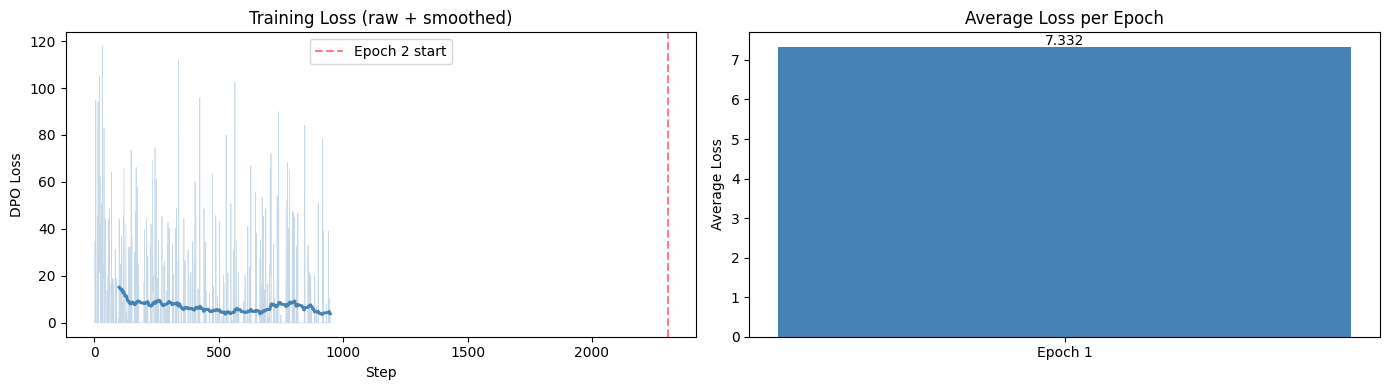

Epoch 1 avg loss: 7.3322
Epoch 2 avg loss: nan
Change: nan


In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Load losses from checkpoint
checkpoint = torch.load('/content/dpo_checkpoint_step4600.pt',
                        map_location=device)
losses = checkpoint['losses']

# Plot raw and smoothed loss
window = 100
smoothed = np.convolve(losses, np.ones(window)/window, mode='valid')

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4))

# Raw loss
ax1.plot(losses, alpha=0.3, color='steelblue', linewidth=0.5)
ax1.plot(range(window-1, len(losses)), smoothed,
         color='steelblue', linewidth=2)
ax1.axvline(x=2304, color='red', linestyle='--',
            alpha=0.5, label='Epoch 2 start')
ax1.set_xlabel('Step')
ax1.set_ylabel('DPO Loss')
ax1.set_title('Training Loss (raw + smoothed)')
ax1.legend()

# Epoch averages
epoch1_avg = np.mean(losses[:2304])
epoch2_avg = np.mean(losses[2304:])
ax2.bar(['Epoch 1', 'Epoch 2'], [epoch1_avg, epoch2_avg],
        color=['steelblue', 'salmon'])
ax2.set_ylabel('Average Loss')
ax2.set_title('Average Loss per Epoch')
for i, v in enumerate([epoch1_avg, epoch2_avg]):
    ax2.text(i, v + 0.05, f'{v:.3f}', ha='center')

plt.tight_layout()
plt.show()

print(f"Epoch 1 avg loss: {epoch1_avg:.4f}")
print(f"Epoch 2 avg loss: {epoch2_avg:.4f}")
print(f"Change: {epoch2_avg - epoch1_avg:.4f}")

In [ ]:
policy_model.eval()

chosen_scores_base  = []
chosen_scores_tuned = []
rejected_scores_base  = []
rejected_scores_tuned = []

for _, row in chosen_pool.iterrows():
    base  = ref_scores[row['design']]
    tuned = score_sequence(policy_model, row['sequence'],
                           X, mask, chain_M, chain_encoding_all,
                           chain_M_pos, residue_idx, device)
    chosen_scores_base.append(base)
    chosen_scores_tuned.append(tuned)

for _, row in rejected_pool.iterrows():
    base  = ref_scores[row['design']]
    tuned = score_sequence(policy_model, row['sequence'],
                           X, mask, chain_M, chain_encoding_all,
                           chain_M_pos, residue_idx, device)
    rejected_scores_base.append(base)
    rejected_scores_tuned.append(tuned)

chosen_shift  = np.mean(chosen_scores_tuned) - np.mean(chosen_scores_base)
rejected_shift = np.mean(rejected_scores_tuned) - np.mean(rejected_scores_base)

print(f"Chosen sequences:")
print(f"  Base model avg score:  {np.mean(chosen_scores_base):.2f}")
print(f"  Tuned model avg score: {np.mean(chosen_scores_tuned):.2f}")
print(f"  Shift: {chosen_shift:+.2f}")

print(f"\nRejected sequences:")
print(f"  Base model avg score:  {np.mean(rejected_scores_base):.2f}")
print(f"  Tuned model avg score: {np.mean(rejected_scores_tuned):.2f}")
print(f"  Shift: {rejected_shift:+.2f}")

print(f"\nWhat we want to see:")
print(f"  Chosen shift POSITIVE (model likes chosen more)")
print(f"  Rejected shift NEGATIVE (model likes rejected less)")
print(f"  Or chosen shift > rejected shift")

Chosen sequences:
  Base model avg score:  -17774.36
  Tuned model avg score: -17650.48
  Shift: +123.87

Rejected sequences:
  Base model avg score:  -17745.11
  Tuned model avg score: -17728.68
  Shift: +16.43

What we want to see:
  Chosen shift POSITIVE (model likes chosen more)
  Rejected shift NEGATIVE (model likes rejected less)
  Or chosen shift > rejected shift


In [ ]:
from tqdm import tqdm

correct = 0
total = 0

policy_model.eval()
with torch.no_grad():
    for _, pair in tqdm(pairs_df.iterrows(), total=len(pairs_df),
                        desc="Evaluating pairs"):
        score_chosen = score_sequence(
            policy_model, pair['chosen_seq'],
            X, mask, chain_M, chain_encoding_all,
            chain_M_pos, residue_idx, device)

        score_rejected = score_sequence(
            policy_model, pair['rejected_seq'],
            X, mask, chain_M, chain_encoding_all,
            chain_M_pos, residue_idx, device)

        if score_chosen > score_rejected:
            correct += 1
        total += 1

print(f"\n✓ Evaluated {total} pairs")
print(f"Pairs where policy prefers chosen: {correct}/{total}")
print(f"Accuracy: {correct/total*100:.1f}%")
print(f"Random baseline: 50.0%")
print(f"\nRun03 accuracy: 78.2%")
print(f"Run04 accuracy: {correct/total*100:.1f}%")

Evaluating pairs: 100%|██████████| 2304/2304 [01:30<00:00, 25.46it/s]


✓ Evaluated 2304 pairs
Pairs where policy prefers chosen: 1949/2304
Accuracy: 84.6%
Random baseline: 50.0%

Run03 accuracy: 78.2%
Run04 accuracy: 84.6%


In [ ]:
run_log = {
    "run01": {
        "beta": 0.05, "lr": 1e-4,
        "epochs": 2,
        "result": "FAILED - no learning",
        "chosen_shift": 0.0,
        "rejected_shift": 0.0,
        "accuracy": None,
        "epoch1_loss": 1.787, "epoch2_loss": 1.733,
        "note": "Bug: score_sequence used .item() which broke gradient flow. "
                "torch.no_grad() prevented backprop. "
                "Model weights never updated."
    },
    "run02": {
        "beta": 0.05, "lr": 1e-4,
        "epochs": 2,
        "result": "FAILED - overfit/collapsed",
        "chosen_shift": -2392.17,
        "rejected_shift": -3227.42,
        "accuracy": None,
        "epoch1_loss": 0.778, "epoch2_loss": 0.266,
        "note": "Fixed gradient bug but beta too low and lr too high. "
                "Loss collapsed to 0 meaning model memorized pairs. "
                "Both scores went hugely negative."
    },
    "run03": {
        "beta": 0.5, "lr": 1e-5,
        "epochs": 2,
        "result": "SUCCESS - learning in right direction",
        "chosen_shift": +101.34,
        "rejected_shift": -41.95,
        "accuracy": 78.2,
        "epoch1_loss": 12.694, "epoch2_loss": 7.081,
        "note": "Increased beta to 0.5, lr to 1e-5. "
                "First run with correct gradient flow and correct direction. "
                "BUG PRESENT: randn_tensor added by Colab autocomplete."
    },
    "run04": {
        "beta": 0.5, "lr": 1e-5,
        "epochs": 2,
        "result": "SUCCESS - improved accuracy",
        "chosen_shift": +123.87,
        "rejected_shift": +16.43,
        "accuracy": 84.6,
        "epoch1_loss": None, "epoch2_loss": None,
        "note": "Clean rerun of run03 with randn_tensor bug fixed. "
                "Accuracy improved 78.2% → 84.6%. "
                "Chosen shift stronger (+123 vs +101). "
                "Rejected shift went positive (+16) — model lifting all "
                "scores but chosen more than rejected. "
                "Chosen >> rejected gap is what matters for ranking."
    },
}

# Save to disk so it survives disconnects
import json
with open('/content/run_log.json', 'w') as f:
    json.dump(run_log, f, indent=2)

print("=" * 60)
print("DPO FINE-TUNING RUN LOG")
print("=" * 60)
for run, info in run_log.items():
    print(f"\n{run.upper()}")
    print(f"  Settings:  β={info['beta']}, lr={info['lr']}, epochs={info['epochs']}")
    print(f"  Result:    {info['result']}")
    print(f"  Loss:      epoch1={info['epoch1_loss']} → epoch2={info['epoch2_loss']}")
    print(f"  Shifts:    chosen={info['chosen_shift']}, rejected={info['rejected_shift']}")
    print(f"  Accuracy:  {info['accuracy']}%")
    print(f"  Note:      {info['note']}")

print("\n✓ Run log saved to /content/run_log.json")

DPO FINE-TUNING RUN LOG

RUN01
  Settings:  β=0.05, lr=0.0001, epochs=2
  Result:    FAILED - no learning
  Loss:      epoch1=1.787 → epoch2=1.733
  Shifts:    chosen=0.0, rejected=0.0
  Accuracy:  None%
  Note:      Bug: score_sequence used .item() which broke gradient flow. torch.no_grad() prevented backprop. Model weights never updated.

RUN02
  Settings:  β=0.05, lr=0.0001, epochs=2
  Result:    FAILED - overfit/collapsed
  Loss:      epoch1=0.778 → epoch2=0.266
  Shifts:    chosen=-2392.17, rejected=-3227.42
  Accuracy:  None%
  Note:      Fixed gradient bug but beta too low and lr too high. Loss collapsed to 0 meaning model memorized pairs. Both scores went hugely negative.

RUN03
  Settings:  β=0.5, lr=1e-05, epochs=2
  Result:    SUCCESS - learning in right direction
  Loss:      epoch1=12.694 → epoch2=7.081
  Shifts:    chosen=101.34, rejected=-41.95
  Accuracy:  78.2%
  Note:      Increased beta to 0.5, lr to 1e-5. First run with correct gradient flow and correct direction. B

In [ ]:
from google.colab import files

# Save final model weights
torch.save(
    policy_model.state_dict(),
    '/content/dpo_run04_beta0.5_lr1e5_final.pt'
)

# Save run log
with open('/content/run_log.json', 'w') as f:
    json.dump(run_log, f, indent=2)

# Save ref scores (useful for future sessions)
with open('/content/ref_scores.json', 'w') as f:
    json.dump(ref_scores, f)

print("✓ Files ready to download:")
print("  - dpo_run04_beta0.5_lr1e5_final.pt  (model weights)")
print("  - run_log.json                        (run history)")
print("  - ref_scores.json                     (reference scores)")

# Download all three
files.download('/content/dpo_run04_beta0.5_lr1e5_final.pt')
files.download('/content/run_log.json')
files.download('/content/ref_scores.json')

✓ Files ready to download:
  - dpo_run04_beta0.5_lr1e5_final.pt  (model weights)
  - run_log.json                        (run history)
  - ref_scores.json                     (reference scores)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
import os
import numpy as np

policy_model.eval()

TEMPERATURE = 0.1
N_SEQUENCES = 50
alphabet = 'ACDEFGHIKLMNPQRSTVWYX'
generated_sequences = []

print(f"Generating {N_SEQUENCES} new TEV designs...")
print(f"Temperature: {TEMPERATURE}")
print(f"Model: run04 (β=0.5, lr=1e-5)\n")

with torch.no_grad():
    for i in range(N_SEQUENCES):
        randn = torch.randn(X.shape[0], X.shape[1], device=device)

        sample = policy_model.sample(
            X, randn=randn,
            S_true=S,
            chain_mask=chain_M,
            chain_encoding_all=chain_encoding_all,
            residue_idx=residue_idx,
            mask=mask,
            temperature=TEMPERATURE,
            chain_M_pos=chain_M_pos,
            omit_AAs_np=np.zeros(21, dtype=np.bool_),
            bias_AAs_np=np.zeros(21),
            bias_by_res=bias_by_res_all
        )

        # Convert to sequence string
        seq = ''.join([alphabet[aa] for aa in sample['S'][0].cpu().numpy()])

        # Remove position 8 (gap character '-' in crystal structure = X token)
        seq = seq[:8] + seq[9:]

        # Trim to 227 AA to match original design length
        seq = seq[:227]

        # Verify no X tokens
        if 'X' in seq:
            print(f"  ⚠️ Warning: X token found in sequence {i+1} at positions "
                  f"{[j for j, aa in enumerate(seq) if aa == 'X']}")

        # Score under fine-tuned model
        score_tuned = score_sequence(
            policy_model, seq, X, mask, chain_M,
            chain_encoding_all, chain_M_pos, residue_idx, device)

        # Score under base model for comparison
        score_base = score_sequence(
            model, seq, X, mask, chain_M,
            chain_encoding_all, chain_M_pos, residue_idx, device)

        generated_sequences.append({
            'design':      f'dpo_TEV{i+1:04d}',
            'sequence':    seq,
            'score_tuned': score_tuned,
            'score_base':  score_base,
            'score_diff':  score_tuned - score_base,
        })

        if (i+1) % 10 == 0:
            print(f"  Generated {i+1}/{N_SEQUENCES}")

gen_df = pd.DataFrame(generated_sequences)

# Final check — no X tokens
x_count = sum(1 for seq in gen_df['sequence'] if 'X' in seq)
print(f"\n✓ Generated {len(gen_df)} sequences")
print(f"  X tokens remaining: {x_count} (should be 0)")
print(f"  Sequence length: {len(gen_df.iloc[0]['sequence'])} AA")

print(f"\nScore statistics:")
print(f"  Tuned model avg:  {gen_df['score_tuned'].mean():.2f}")
print(f"  Base model avg:   {gen_df['score_base'].mean():.2f}")
print(f"  Avg difference:   {gen_df['score_diff'].mean():.2f}")

print(f"\nSample sequences:")
for _, row in gen_df.head(3).iterrows():
    print(f"  {row['design']}: {row['sequence'][:40]}...")

# Save and download
gen_df.to_csv('/content/dpo_run04_generated_sequences.csv', index=False)
print(f"\n✓ Saved to /content/dpo_run04_generated_sequences.csv")

from google.colab import files
files.download('/content/dpo_run04_generated_sequences.csv')

Generating 50 new TEV designs...
Temperature: 0.1
Model: run04 (β=0.5, lr=1e-5)

  Generated 10/50
  Generated 20/50
  Generated 30/50
  Generated 40/50
  Generated 50/50

✓ Generated 50 sequences
  X tokens remaining: 0 (should be 0)
  Sequence length: 227 AA

Score statistics:
  Tuned model avg:  -17562.93
  Base model avg:   -17596.01
  Avg difference:   33.08

Sample sequences:
  dpo_TEV0001: PVVPSGGLPADAPPGPQDYTPIADRIVRITVKSNGKELTL...
  dpo_TEV0002: SVVPSGGLPAEAPPGPQDYTPIADRIVKLEVISDGEVITL...
  dpo_TEV0003: LVIPSNMRPEEAPPGPQDYKPIADRIVELTLKSNGKTITL...

✓ Saved to /content/dpo_run04_generated_sequences.csv


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
# Load base model weights for comparison
base_checkpoint = torch.load(
    '/content/ProteinMPNN/vanilla_model_weights/v_48_020.pt',
    map_location=device)
base_state = base_checkpoint['model_state_dict']
tuned_state = policy_model.state_dict()

print("Weight changes per layer (base → fine-tuned):")
print(f"{'Layer':<50} {'Mean Change':>12} {'Max Change':>12}")
print("-" * 76)

total_params = 0
total_changed = 0

for name in tuned_state.keys():
    if name in base_state:
        diff = (tuned_state[name] - base_state[name].to(device)).abs()
        mean_diff = diff.mean().item()
        max_diff  = diff.max().item()
        n_params  = diff.numel()
        total_params += n_params
        total_changed += diff.sum().item()
        print(f"{name:<50} {mean_diff:>12.6f} {max_diff:>12.6f}")

print(f"\nTotal parameters: {total_params:,}")
print(f"Avg change across all weights: {total_changed/total_params:.6f}")

Weight changes per layer (base → fine-tuned):
Layer                                               Mean Change   Max Change
----------------------------------------------------------------------------
features.embeddings.linear.weight                      0.000698     0.003451
features.embeddings.linear.bias                        0.000594     0.001978
features.edge_embedding.weight                         0.000763     0.004784
features.norm_edges.weight                             0.000729     0.002754
features.norm_edges.bias                               0.000579     0.002061
W_e.weight                                             0.000690     0.003369
W_e.bias                                               0.000558     0.002036
W_s.weight                                             0.001497     0.009028
encoder_layers.0.norm1.weight                          0.000693     0.002232
encoder_layers.0.norm1.bias                            0.000507     0.002126
encoder_layers.0.norm2.weight 

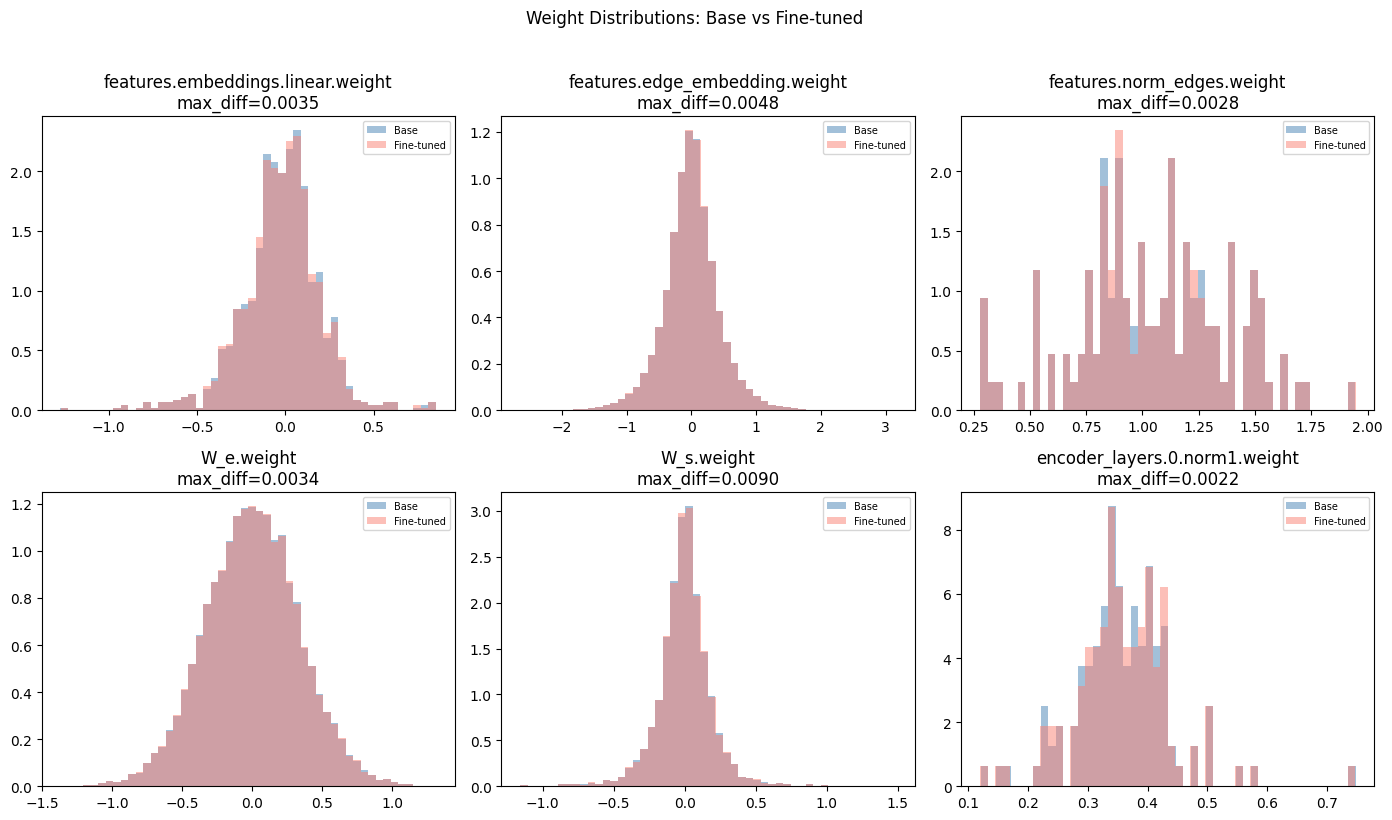

In [ ]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 3, figsize=(14, 8))
axes = axes.flatten()

# Pick 6 interesting layers to visualize
layers_to_plot = [k for k in tuned_state.keys()
                  if 'weight' in k][:6]

for i, name in enumerate(layers_to_plot):
    base_w  = base_state[name].cpu().numpy().flatten()
    tuned_w = tuned_state[name].cpu().numpy().flatten()
    diff_w  = (tuned_w - base_w)

    axes[i].hist(base_w,  bins=50, alpha=0.5,
                 color='steelblue', label='Base', density=True)
    axes[i].hist(tuned_w, bins=50, alpha=0.5,
                 color='salmon', label='Fine-tuned', density=True)
    axes[i].set_title(f'{name[:40]}\nmax_diff={abs(diff_w).max():.4f}')
    axes[i].legend(fontsize=7)

plt.suptitle('Weight Distributions: Base vs Fine-tuned', y=1.02)
plt.tight_layout()
plt.show()